In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/NTCIR-19/input_pairs.csv')

In [71]:
df

,id,ペア番号,ペア,痛み,しびれ,振る舞い,トリアージ,質問,回答,ペアのベクトル,cos_sim_ひし形_全通り_頭痛_1,cos_sim_ひし形_全通り_頭痛_2,cos_sim_ひし形_全通り_頭痛_3,cos_sim_ひし形_直接,採用ペア_ひし形_全通り_頭痛_1,採用ペア_ひし形_全通り_頭痛_2,採用ペア_ひし形_全通り_頭痛_3,採用ペア_ひし形_直接
0,v001-01,0,救急ですか、火事ですか。 救急です。父のことでお願いします。,0,0,0,1,救急ですか、火事ですか。,救急です。父のことでお願いします。,"[-0.19299201667308807, 0.6872438788414001, -0....",0.306688,0.161881,0.436759,0.556005,False,False,True,True
1,v001-01,1,どうしましたか。 さっき夕食中に、急に頭が割れるほど痛いと言って倒れ込みました。,0,0,0,1,どうしましたか。,さっき夕食中に、急に頭が割れるほど痛いと言って倒れ込みました。,"[-0.22492866218090057, 0.44413238763809204, 0....",0.317243,0.055474,0.385697,0.489653,False,False,False,False
2,v001-01,2,頭の痛みは急に始まったんですね。 はい、突然です。今までこんな痛がり方はありません。,0,0,0,1,頭の痛みは急に始まったんですね。,はい、突然です。今までこんな痛がり方はありません。,"[-0.39414942264556885, 0.11081638187170029, -0...",0.369534,0.219158,0.455676,0.508696,True,True,True,False
3,v001-01,3,手や足にしびれがあるとか、片方が動かしにくい様子はありますか。 あります。左腕がしびれると言...,0,0,0,1,手や足にしびれがあるとか、片方が動かしにくい様子はありますか。,あります。左腕がしびれると言っていて、左足もうまく動かせていません。,"[0.5903365015983582, -0.35502269864082336, 0.2...",0.368252,0.184430,0.377666,0.541500,True,False,False,True
4,v001-01,4,普段と違って、話し方や反応がおかしいところはありますか。 はい、あります。呼んでも返事が遅く...,0,0,0,1,普段と違って、話し方や反応がおかしいところはありますか。,はい、あります。呼んでも返事が遅くて、言葉も少しはっきりしません。,"[-0.33301791548728943, 0.26256924867630005, 0....",0.306560,0.187755,0.400798,0.475115,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,v027-06,0,救急ですか、火事ですか。 救急です。近所の人が頭痛でうずくまっていて、様子を見てほしいです。,2,2,2,0,救急ですか、火事ですか。,救急です。近所の人が頭痛でうずくまっていて、様子を見てほしいです。,"[-0.18330919742584229, 0.4083477854728699, 0.0...",0.435586,0.112723,0.418977,0.548228,True,False,False,True
812,v027-06,1,どうしましたか。 アパートの共用廊下で会ったら、頭が痛くて部屋まで戻れないと言って座りこんで...,2,2,2,0,どうしましたか。,アパートの共用廊下で会ったら、頭が痛くて部屋まで戻れないと言って座りこんでしまいました。,"[0.03332783281803131, -0.44131410121917725, 0....",0.334801,0.175579,0.348028,0.385286,False,False,False,False
813,v027-06,2,その頭痛は突然ひどくなったのか、前からあったのか分かりますか。 すみません、私が会った時には...,2,2,2,0,その頭痛は突然ひどくなったのか、前からあったのか分かりますか。,すみません、私が会った時にはもうつらそうで、いつからかは聞いてもよく分かりませんでした。,"[-0.37357866764068604, 0.05960867181420326, 0....",0.344984,0.176049,0.605912,0.455641,False,False,True,False
814,v027-06,3,手足のしびれや麻痺はありそうですか。 そこは分からないです。私もあまり触れられなくて、本人も...,2,2,2,0,手足のしびれや麻痺はありそうですか。,そこは分からないです。私もあまり触れられなくて、本人も頭のことしか言わないんです。,"[-0.5109606981277466, -0.27680131793022156, 0....",0.308941,0.332899,0.398021,0.513730,False,True,False,False


In [ ]:
df.columns

Index(['id', 'ペア番号', 'ペア', '痛み', 'しびれ', '振る舞い', 'トリアージ', '質問', '回答', 'ペアのベクトル',
       'cos_sim_ひし形_全通り_頭痛_1', 'cos_sim_ひし形_全通り_頭痛_2', 'cos_sim_ひし形_全通り_頭痛_3',
       'cos_sim_ひし形_直接', '採用ペア_ひし形_全通り_頭痛_1', '採用ペア_ひし形_全通り_頭痛_2',
       '採用ペア_ひし形_全通り_頭痛_3', '採用ペア_ひし形_直接'],
      dtype='object')

In [ ]:
df_painful = df[['id', 'ペア番号', 'ペア', '痛み', '質問', '回答', '採用ペア_ひし形_全通り_頭痛_1']]

In [ ]:
df_painful

,id,ペア番号,ペア,痛み,質問,回答,採用ペア_ひし形_全通り_頭痛_1
0,v001-01,0,救急ですか、火事ですか。 救急です。父のことでお願いします。,0,救急ですか、火事ですか。,救急です。父のことでお願いします。,False
1,v001-01,1,どうしましたか。 さっき夕食中に、急に頭が割れるほど痛いと言って倒れ込みました。,0,どうしましたか。,さっき夕食中に、急に頭が割れるほど痛いと言って倒れ込みました。,False
2,v001-01,2,頭の痛みは急に始まったんですね。 はい、突然です。今までこんな痛がり方はありません。,0,頭の痛みは急に始まったんですね。,はい、突然です。今までこんな痛がり方はありません。,True
3,v001-01,3,手や足にしびれがあるとか、片方が動かしにくい様子はありますか。 あります。左腕がしびれると言...,0,手や足にしびれがあるとか、片方が動かしにくい様子はありますか。,あります。左腕がしびれると言っていて、左足もうまく動かせていません。,True
4,v001-01,4,普段と違って、話し方や反応がおかしいところはありますか。 はい、あります。呼んでも返事が遅く...,0,普段と違って、話し方や反応がおかしいところはありますか。,はい、あります。呼んでも返事が遅くて、言葉も少しはっきりしません。,False
...,...,...,...,...,...,...,...
811,v027-06,0,救急ですか、火事ですか。 救急です。近所の人が頭痛でうずくまっていて、様子を見てほしいです。,2,救急ですか、火事ですか。,救急です。近所の人が頭痛でうずくまっていて、様子を見てほしいです。,True
812,v027-06,1,どうしましたか。 アパートの共用廊下で会ったら、頭が痛くて部屋まで戻れないと言って座りこんで...,2,どうしましたか。,アパートの共用廊下で会ったら、頭が痛くて部屋まで戻れないと言って座りこんでしまいました。,False
813,v027-06,2,その頭痛は突然ひどくなったのか、前からあったのか分かりますか。 すみません、私が会った時には...,2,その頭痛は突然ひどくなったのか、前からあったのか分かりますか。,すみません、私が会った時にはもうつらそうで、いつからかは聞いてもよく分かりませんでした。,False
814,v027-06,3,手足のしびれや麻痺はありそうですか。 そこは分からないです。私もあまり触れられなくて、本人も...,2,手足のしびれや麻痺はありそうですか。,そこは分からないです。私もあまり触れられなくて、本人も頭のことしか言わないんです。,False


# cos類似度が高いペアだけを抽出する関数

In [ ]:
def input_filtered_function(df_name, hishigata, label):
    # '採用ペア_ひし形_全通り_頭痛_1'がTrueの行をフィルタリング
    df_filtered = df_name[df_name[hishigata] == True].copy()

    # 'id'ごとに'ペア番号'を結合し、指定されたlabel（'痛み'など）も抽出
    df_input = df_filtered.groupby('id').agg(
        ペア=('ペア', lambda x: " ".join(x)), # 文字列結合のために型変換を追加すると安全です
        痛み=(label, 'first')
    ).reset_index()

    return df_input # 修正：処理したデータフレームを返す必要があります

In [ ]:
df_painful_input = input_filtered_function(df_painful, '採用ペア_ひし形_全通り_頭痛_1', '痛み')

In [ ]:
df_painful_input

,id,ペア,痛み
0,v001-01,頭の痛みは急に始まったんですね。 はい、突然です。今までこんな痛がり方はありません。 手や足...,0
1,v001-02,どうしましたか。 会議中に突然頭を押さえて、今すぐ救急車を呼んでくれって言い出しました。,0
2,v001-03,救急ですか、火事ですか。 救急です。友人が急な頭痛で動けません。 どうしましたか。 公園で話...,0
3,v001-04,しびれたり、片側の手足が動かしにくいことはありますか。 あります。右側の腕が上がりにくくて、...,0
4,v001-05,救急ですか、火事ですか。 救急です。学校の先生が急に頭痛を訴えています。 どうしましたか。 ...,0
...,...,...,...
157,v027-02,どうしましたか。 事務所で急に席を立って、頭が痛いから無理だと言ってしゃがみこんでしまいました。,2
158,v027-03,救急ですか、火事ですか。 救急です。友人がカフェで頭痛を起こして動けなくなっています。,2
159,v027-04,しびれや麻痺の有無はどうでしょう。左右差など見られますか。 今は痛みの訴えが強くて、そこまで...,2
160,v027-05,救急ですか、火事ですか。 救急です。学校の職員ですが、生徒が頭痛で保健室で苦しんでいます。 ...,2


# 1. セットアップ：ライブラリのインストールとインポート

In [ ]:
# 必要なライブラリをインストール
# - transformers, sentencepiece: BERTモデル本体
# - fugashi, unidic-lite: 日本語形態素解析（ストップワード除去用）
# - fugashi は UniDic (lite版) を使用。品詞情報を取得できる。
!pip install -q transformers sentencepiece fugashi unidic-lite accelerate


In [ ]:
import os
import json
import time
import random
import itertools
import html as html_module
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
# 日本語フォントが文字化けする場合、Colab上で以下を実行してフォントを入れてください：
# !pip install -q japanize-matplotlib
try:
    import japanize_matplotlib  # noqa: F401
except ImportError:
    print("japanize_matplotlib が無い場合、グラフの日本語が文字化けすることがあります。"
          "必要であれば `!pip install japanize-matplotlib` を実行してください。")

import fugashi

print("transformers / torch / fugashi のインポートに成功しました。")


japanize_matplotlib が無い場合、グラフの日本語が文字化けすることがあります。必要であれば `!pip install japanize-matplotlib` を実行してください。
transformers / torch / fugashi のインポートに成功しました。


# 2. 実行環境の確認と乱数シードの固定

In [ ]:
# GPUの有無を確認。なければCPUにフォールバックする。
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用デバイス:", DEVICE)
if torch.cuda.is_available():
    print("GPU名:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPUが利用できません。Colabの場合は「ランタイム」→「ランタイムのタイプを変更」でGPUを選択してください。")
    print("   CPUでも動作しますが、540回の学習はかなり時間がかかります。")


使用デバイス: cuda
GPU名: NVIDIA A100-SXM4-80GB


In [ ]:
SEED = 42

def set_seed(seed: int = SEED):
    """再現性確保のため、各種ライブラリの乱数シードを固定する。"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"乱数シードを {SEED} に固定しました。")


乱数シードを 42 に固定しました。


# 3. データの確認

In [ ]:
TEXT_COL = "ペア"
LABEL_COL = "痛み"

# ラベルの分布確認
print("=== ラベル(痛み)の分布 ===")
print(df_painful_input[LABEL_COL].value_counts().sort_index())
print()
print(df_painful_input[LABEL_COL].value_counts(normalize=True).sort_index())


=== ラベル(痛み)の分布 ===
痛み
0    54
1    54
2    54
Name: count, dtype: int64

痛み
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64


In [ ]:
# 文字数の分布も確認しておく（BERTの最大トークン長512に対して余裕があるか）
char_len = df_painful_input[TEXT_COL].str.len()
print("=== 文字数の統計 ===")
print(char_len.describe())
print()
print("=== ラベル別の文字数統計 ===")
print(df_painful_input.groupby(LABEL_COL)[TEXT_COL].apply(lambda s: s.str.len().describe()))


=== 文字数の統計 ===
count    162.000000
mean      88.975309
std       55.994227
min       36.000000
25%       50.250000
50%       63.500000
75%      114.750000
max      273.000000
Name: ペア, dtype: float64

=== ラベル別の文字数統計 ===
痛み       
0   count     54.000000
    mean      73.611111
    std       47.607839
    min       37.000000
    25%       47.000000
    50%       56.000000
    75%       85.500000
    max      273.000000
1   count     54.000000
    mean     105.685185
    std       65.482195
    min       36.000000
    25%       53.750000
    50%       75.000000
    75%      150.500000
    max      252.000000
2   count     54.000000
    mean      87.629630
    std       49.427781
    min       37.000000
    25%       52.000000
    50%       65.000000
    75%      118.500000
    max      251.000000
Name: ペア, dtype: float64


In [ ]:

NUM_LABELS = df_painful_input[LABEL_COL].nunique()
print(f"クラス数: {NUM_LABELS}")
assert NUM_LABELS == 3, "想定外のクラス数です。データを確認してください。"


クラス数: 3


# 4. ストップワード除去の実装

In [ ]:
tagger = fugashi.Tagger()

# 個別に除去したい語（品詞に関わらず除去する語）。自由に追加・編集してよい。
STOPWORD_EXTRA_WORDS = set([
    "の", "は", "を", "に", "が", "で", "と", "も", "から", "より",
    "へ", "や", "など", "ので", "けど", "けれど", "、", "。", "です", "ます"
])


def remove_stopwords(text: str) -> str:
    """
    fugashiで形態素解析し、STOPWORD_POS_LIST に含まれる品詞、
    または STOPWORD_EXTRA_WORDS に含まれる表層形のトークンを除去して
    再連結したテキストを返す。

    BERTのサブワード分割とは独立した「単語単位」の処理であることに注意。
    除去後、単語間は単純に連結する（空白は入れない。日本語の自然な見た目を保つため）。
    """
    tokens = []
    for word in tagger(text):
        pos_major = word.feature.pos1  # 品詞の大分類（例：助詞、名詞 等）
        surface = word.surface
        if surface in STOPWORD_EXTRA_WORDS:
            continue
        tokens.append(surface)
    return "".join(tokens)


# 動作確認
sample_text = df_painful_input[TEXT_COL].iloc[0]
print("=== 元のテキスト ===")
print(sample_text)
print()
print("=== ストップワード除去後 ===")
print(remove_stopwords(sample_text))


=== 元のテキスト ===
頭の痛みは急に始まったんですね。 はい、突然です。今までこんな痛がり方はありません。 手や足にしびれがあるとか、片方が動かしにくい様子はありますか。 あります。左腕がしびれると言っていて、左足もうまく動かせていません。

=== ストップワード除去後 ===
頭痛み急始まったんねはい突然今までこんな痛がり方ありません手足しびれあるか片方動かしにくい様子ありかあり左腕しびれる言っていて左足うまく動かせていません


In [ ]:

# 両方のバージョンを事前に作成しておく（学習時に都度形態素解析しなくて済むようにキャッシュ）
df_painful_input["text_with_stopwords"] = df_painful_input[TEXT_COL]
df_painful_input["text_no_stopwords"] = df_painful_input[TEXT_COL].apply(remove_stopwords)

df_painful_input[[TEXT_COL, "text_with_stopwords", "text_no_stopwords"]].head(3)


,ペア,text_with_stopwords,text_no_stopwords
0,頭の痛みは急に始まったんですね。 はい、突然です。今までこんな痛がり方はありません。 手や足...,頭の痛みは急に始まったんですね。 はい、突然です。今までこんな痛がり方はありません。 手や足...,頭痛み急始まったんねはい突然今までこんな痛がり方ありません手足しびれあるか片方動かしにくい様...
1,どうしましたか。 会議中に突然頭を押さえて、今すぐ救急車を呼んでくれって言い出しました。,どうしましたか。 会議中に突然頭を押さえて、今すぐ救急車を呼んでくれって言い出しました。,どうしましたか会議中突然頭押さえて今すぐ救急車呼んくれって言い出しました
2,救急ですか、火事ですか。 救急です。友人が急な頭痛で動けません。 どうしましたか。 公園で話...,救急ですか、火事ですか。 救急です。友人が急な頭痛で動けません。 どうしましたか。 公園で話...,救急か火事か救急友人急な頭痛動けませんどうしましたか公園話していたらいきなり後頭部ものすごく...


# 5. 実験設定：グリッドサーチの定義

In [ ]:
# ===== ここを編集すれば実験範囲を変更できる =====
MODEL_NAMES = [
    "cl-tohoku/bert-base-japanese-v3",
    "alabnii/jmedroberta-base-sentencepiece",
]
USE_STOPWORDS_OPTIONS = [True, False]
LEARNING_RATES = [1e-5, 2e-5, 5e-5]
EPOCHS_LIST = [3, 5, 10]
BATCH_SIZES = [4, 8, 16]
N_FOLDS = 5
MAX_LENGTH = 512  # 文字数調査の結果、最大でも300字台なのでこれで十分余裕がある
# ================================================

# 全組み合わせ（108通り）を生成
GRID_SETTINGS = []
for model_name, use_sw, lr, epochs, bs in itertools.product(
    MODEL_NAMES, USE_STOPWORDS_OPTIONS, LEARNING_RATES, EPOCHS_LIST, BATCH_SIZES
):
    GRID_SETTINGS.append({
        "run_id": None,  # 後で連番を振る
        "model_name": model_name,
        "use_stopwords": use_sw,
        "learning_rate": lr,
        "num_epochs": epochs,
        "batch_size": bs,
    })

for i, setting in enumerate(GRID_SETTINGS):
    setting["run_id"] = f"run_{i:03d}"

print(f"全設定数: {len(GRID_SETTINGS)} 通り")
print(f"5-fold を含めた総学習回数: {len(GRID_SETTINGS) * N_FOLDS} 回")
print()
print("設定の例（先頭3件）:")
for s in GRID_SETTINGS[:3]:
    print(s)


全設定数: 108 通り
5-fold を含めた総学習回数: 540 回

設定の例（先頭3件）:
{'run_id': 'run_000', 'model_name': 'cl-tohoku/bert-base-japanese-v3', 'use_stopwords': True, 'learning_rate': 1e-05, 'num_epochs': 3, 'batch_size': 4}
{'run_id': 'run_001', 'model_name': 'cl-tohoku/bert-base-japanese-v3', 'use_stopwords': True, 'learning_rate': 1e-05, 'num_epochs': 3, 'batch_size': 8}
{'run_id': 'run_002', 'model_name': 'cl-tohoku/bert-base-japanese-v3', 'use_stopwords': True, 'learning_rate': 1e-05, 'num_epochs': 3, 'batch_size': 16}


In [ ]:
# 設定一覧をDataFrameとしても確認できるようにしておく
settings_df = pd.DataFrame(GRID_SETTINGS)
settings_df.head(10)


,run_id,model_name,use_stopwords,learning_rate,num_epochs,batch_size
0,run_000,cl-tohoku/bert-base-japanese-v3,True,0.00001,3,4
1,run_001,cl-tohoku/bert-base-japanese-v3,True,0.00001,3,8
2,run_002,cl-tohoku/bert-base-japanese-v3,True,0.00001,3,16
3,run_003,cl-tohoku/bert-base-japanese-v3,True,0.00001,5,4
4,run_004,cl-tohoku/bert-base-japanese-v3,True,0.00001,5,8
5,run_005,cl-tohoku/bert-base-japanese-v3,True,0.00001,5,16
6,run_006,cl-tohoku/bert-base-japanese-v3,True,0.00001,10,4
7,run_007,cl-tohoku/bert-base-japanese-v3,True,0.00001,10,8
8,run_008,cl-tohoku/bert-base-japanese-v3,True,0.00001,10,16
9,run_009,cl-tohoku/bert-base-japanese-v3,True,0.00002,3,4


# 6. Dataset・Tokenizerの準備

In [ ]:
_tokenizer_cache: Dict[str, "AutoTokenizer"] = {}


def get_tokenizer(model_name: str):
    """モデル名ごとにTokenizerをキャッシュして再利用する。"""
    if model_name not in _tokenizer_cache:
        _tokenizer_cache[model_name] = AutoTokenizer.from_pretrained(model_name)
    return _tokenizer_cache[model_name]


class PainTextDataset(Dataset):
    """
    テキストとラベルのリストを受け取り、指定したtokenizerでエンコードするDataset。
    """

    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_length: int = MAX_LENGTH):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoded = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in encoded.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item


print("PainTextDataset を定義しました。")


PainTextDataset を定義しました。


# 7. 学習・評価関数

In [ ]:
def build_model(
    model_name: str,
    tokenizer,
    num_labels: int = NUM_LABELS,
    attn_implementation: Optional[str] = None,
):
    """
    指定したモデル名で分類用モデルを新規にロードする（fold毎に毎回新規初期化する）。

    一部のモデル（例：alabnii/jmedroberta-base-sentencepiece）は、
    tokenizerの実際の語彙数（特殊トークン込み）と model.config.vocab_size が
    1つズレていることがある（既知の不整合）。
    これを放置すると、embedding lookup時にCUDA側で
    「device-side assert triggered」という分かりにくいエラーになる。

    そのため、tokenizerの語彙数とモデルのembeddingサイズが異なる場合は、
    resize_token_embeddings() で自動的に揃える。

    Parameters
    ----------
    attn_implementation : Optional[str]
        通常は None のままでよい（transformersが自動選択する高速な実装、
        多くの場合 `sdpa` が使われる）。
        Attentionの可視化（output_attentions=True）が必要な場合は
        "eager" を指定する。`sdpa` は output_attentions をサポートしないため。
    """
    model_kwargs = {"num_labels": num_labels}
    if attn_implementation is not None:
        model_kwargs["attn_implementation"] = attn_implementation

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, **model_kwargs
    )

    tokenizer_vocab_size = len(tokenizer)
    model_vocab_size = model.config.vocab_size
    if tokenizer_vocab_size != model_vocab_size:
        print(
            f"  [警告] {model_name}: tokenizerの語彙数({tokenizer_vocab_size})と"
            f"モデルのvocab_size({model_vocab_size})が一致しないため、"
            f"resize_token_embeddings({tokenizer_vocab_size}) で補正します。"
        )
        model.resize_token_embeddings(tokenizer_vocab_size)

    return model.to(DEVICE)


def validate_labels(labels: List[int], num_labels: int = NUM_LABELS):
    """
    ラベルが [0, num_labels-1] の範囲内であることを確認する。
    範囲外の値があれば、CUDA assertより先にここで分かりやすいエラーを出す。
    """
    arr = np.array(labels)
    if arr.min() < 0 or arr.max() > (num_labels - 1):
        bad_values = sorted(set(arr[(arr < 0) | (arr > (num_labels - 1))].tolist()))
        raise ValueError(
            f"ラベルの値が想定範囲 [0, {num_labels - 1}] の外にあります。"
            f"範囲外の値: {bad_values}"
        )


def validate_token_ids(input_ids: "torch.Tensor", vocab_size: int):
    """
    トークンIDがモデルのvocabサイズの範囲内であることを確認する。
    （tokenizerとモデルのvocabサイズが不一致だと、embedding lookupでCUDA assertが起きる）
    """
    max_id = int(input_ids.max().item())
    min_id = int(input_ids.min().item())
    if max_id >= vocab_size or min_id < 0:
        raise ValueError(
            f"トークンIDがモデルのvocabサイズ({vocab_size})の範囲外です。"
            f"検出された範囲: [{min_id}, {max_id}]。"
            f"tokenizerとモデルの組み合わせが正しいか確認してください。"
        )


def train_one_fold(
    model_name: str,
    train_texts: List[str],
    train_labels: List[int],
    test_texts: List[str],
    test_labels: List[int],
    learning_rate: float,
    num_epochs: int,
    batch_size: int,
    max_length: int = MAX_LENGTH,
    seed: int = SEED,
) -> Dict:
    """
    1つの設定・1つのfoldについて学習と評価を行う。

    Returns
    -------
    dict:
        accuracy, precision_macro, recall_macro, f1_macro,
        train_time_sec, train_loss_history (List[float], epoch毎),
        y_true, y_pred (混同行列の再現用)
    """
    set_seed(seed)

    # --- 事前チェック（CUDA assert対策） ---
    validate_labels(train_labels)
    validate_labels(test_labels)

    tokenizer = get_tokenizer(model_name)
    model = build_model(model_name, tokenizer)

    # resize_token_embeddings後の「実際の」embeddingサイズを基準にする
    # （build_model内で補正済みのため、ここでは model.config.vocab_size より正確）
    vocab_size = model.get_input_embeddings().num_embeddings

    train_dataset = PainTextDataset(train_texts, train_labels, tokenizer, max_length)
    test_dataset = PainTextDataset(test_texts, test_labels, tokenizer, max_length)

    # 最初の1バッチだけトークンIDの範囲を確認しておく（毎バッチ確認すると遅くなるため）
    sample_batch = train_dataset[0]
    validate_token_ids(sample_batch["input_ids"], vocab_size)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    train_loss_history = []
    start_time = time.time()

    model.train()
    for epoch in range(num_epochs):
        epoch_losses = []
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        train_loss_history.append(float(np.mean(epoch_losses)))

    train_time_sec = time.time() - start_time

    # 評価
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in test_loader:
            labels = batch.pop("labels").to(DEVICE)
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    accuracy = accuracy_score(all_labels, all_preds)
    precision_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall_macro = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    # メモリ解放（多数回学習するため、GPUメモリを使い切らないように都度解放する）
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "train_time_sec": train_time_sec,
        "train_loss_history": train_loss_history,
        "y_true": all_labels,
        "y_pred": all_preds,
    }


print("train_one_fold（事前チェック付き）を定義しました。")


train_one_fold（事前チェック付き）を定義しました。


# 8. メインループ：Grid Search の実行（モデルごとにセルを分割）

In [ ]:
# 入力テキスト列を、ストップワード有無に応じて切り替えるためのマッピング
TEXT_COL_MAP = {
    True: "text_no_stopwords",   # use_stopwords=True は「ストップワードを除去する」という意味
    False: "text_with_stopwords",  # use_stopwords=False は「ストップワードを除去しない（元のまま）」
}
# ※ 列名と意味の対応に注意：
#   use_stopwords=True  -> ストップワード除去を「適用する」 -> text_no_stopwords を使う
#   use_stopwords=False -> ストップワード除去を「適用しない」-> text_with_stopwords(元テキスト)を使う

labels_array = df_painful_input[LABEL_COL].values

# モデルごとの結果を分けて保持する辞書。
# キー：モデル名、値：fold単位の結果レコードのリスト
detail_records_by_model: Dict[str, List[Dict]] = {name: [] for name in MODEL_NAMES}


def run_grid_search_for_model(model_name: str, settings_for_this_model: List[Dict]) -> List[Dict]:
    """
    指定した1つのモデルについて、与えられた設定群（ストップワード×lr×epoch×batch）の
    Stratified 5-fold CVをすべて実行し、fold単位の結果レコードのリストを返す。

    モデルごとに呼び出すことで、エラー発生時に該当モデルだけ再実行できるようにする。
    """
    records = []
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    for setting_idx, setting in enumerate(settings_for_this_model):
        run_id = setting["run_id"]
        use_sw = setting["use_stopwords"]
        lr = setting["learning_rate"]
        epochs = setting["num_epochs"]
        bs = setting["batch_size"]

        text_col_to_use = TEXT_COL_MAP[use_sw]
        texts_array = df_painful_input[text_col_to_use].values

        print(f"[{setting_idx + 1}/{len(settings_for_this_model)}] {run_id} | "
              f"model={model_name} | stopwords={use_sw} | lr={lr} | epochs={epochs} | batch={bs}")

        for fold_idx, (train_idx, test_idx) in enumerate(skf.split(texts_array, labels_array)):
            train_texts = texts_array[train_idx].tolist()
            train_labels = labels_array[train_idx].tolist()
            test_texts = texts_array[test_idx].tolist()
            test_labels = labels_array[test_idx].tolist()

            result = train_one_fold(
                model_name=model_name,
                train_texts=train_texts,
                train_labels=train_labels,
                test_texts=test_texts,
                test_labels=test_labels,
                learning_rate=lr,
                num_epochs=epochs,
                batch_size=bs,
            )

            records.append({
                "run_id": run_id,
                "model_name": model_name,
                "use_stopwords": use_sw,
                "learning_rate": lr,
                "num_epochs": epochs,
                "batch_size": bs,
                "fold": fold_idx,
                "accuracy": result["accuracy"],
                "precision_macro": result["precision_macro"],
                "recall_macro": result["recall_macro"],
                "f1_macro": result["f1_macro"],
                "train_time_sec": result["train_time_sec"],
                "train_loss_history": result["train_loss_history"],
                "y_true": result["y_true"],
                "y_pred": result["y_pred"],
            })

            print(f"    fold {fold_idx}: acc={result['accuracy']:.3f} "
                  f"f1={result['f1_macro']:.3f} time={result['train_time_sec']:.1f}s")

    return records


print("run_grid_search_for_model を定義しました。")
print("次のセルから、モデルごとに実行してください。")


run_grid_search_for_model を定義しました。
次のセルから、モデルごとに実行してください。


## 8-A. 東北大BERT（`cl-tohoku/bert-base-japanese-v3`）のGrid Search

In [ ]:
MODEL_NAME_TOHOKU = "cl-tohoku/bert-base-japanese-v3"

settings_tohoku = [s for s in GRID_SETTINGS if s["model_name"] == MODEL_NAME_TOHOKU]
print(f"このモデルの設定数: {len(settings_tohoku)} （5-foldで{len(settings_tohoku) * N_FOLDS}回学習）")

# 実行（エラーが起きた場合、このセルだけ再実行すればよい）
detail_records_by_model[MODEL_NAME_TOHOKU] = run_grid_search_for_model(
    MODEL_NAME_TOHOKU, settings_tohoku
)

print(f"完了。{MODEL_NAME_TOHOKU} のレコード数: {len(detail_records_by_model[MODEL_NAME_TOHOKU])}")


このモデルの設定数: 54 （5-foldで270回学習）
[1/54] run_000 | model=cl-tohoku/bert-base-japanese-v3 | stopwords=True | lr=1e-05 | epochs=3 | batch=4


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-v3
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

    fold 0: acc=0.485 f1=0.485 time=839.9s


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-v3
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

    fold 3: acc=0.500 f1=0.500 time=2768.6s


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-v3
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

## 8-B. JMedRoBERTa（`alabnii/jmedroberta-base-sentencepiece`）のGrid Search

In [ ]:
MODEL_NAME_JMED = "alabnii/jmedroberta-base-sentencepiece"

settings_jmed = [s for s in GRID_SETTINGS if s["model_name"] == MODEL_NAME_JMED]
print(f"このモデルの設定数: {len(settings_jmed)} （5-foldで{len(settings_jmed) * N_FOLDS}回学習）")

# 実行（エラーが起きた場合、このセルだけ再実行すればよい）
detail_records_by_model[MODEL_NAME_JMED] = run_grid_search_for_model(
    MODEL_NAME_JMED, settings_jmed
)

print(f"完了。{MODEL_NAME_JMED} のレコード数: {len(detail_records_by_model[MODEL_NAME_JMED])}")

このモデルの設定数: 54 （5-foldで270回学習）
[1/54] run_054 | model=alabnii/jmedroberta-base-sentencepiece | stopwords=True | lr=1e-05 | epochs=3 | batch=4


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: alabnii/jmedroberta-base-sentencepiece
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [警告] alabnii/jmedroberta-base-sentencepiece: tokenizerの語彙数(30101)とモデルのvocab_size(30000)が一致しないため、resize_token_embeddings(30101) で補正します。
    fold 0: acc=0.576 f1=0.574 time=8.7s


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: alabnii/jmedroberta-base-sentencepiece
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [警告] alabnii/jmedroberta-base-sentencepiece: tokenizerの語彙数(30101)とモデルのvocab_size(30000)が一致しないため、resize_token_embeddings(30101) で補正します。
    fold 3: acc=0.500 f1=0.496 time=25.1s


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: alabnii/jmedroberta-base-sentencepiece
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [警告] alabnii/jmedroberta-base-sentencepiece: tokenizerの語彙数(30101)とモデルのvocab_size(30000)が一致しないため、resize_token_embeddings(30101) で補正します。
    fold 4: acc=0.562 f1=0.554 time=25.1s
完了。alabnii/jmedroberta-base-sentencepiece のレコード数: 270


## 8-C. 両モデルの結果を結合

In [ ]:
# 両モデルの結果（リスト）を1つに結合する
detail_records = []
for model_name, records in detail_records_by_model.items():
    detail_records.extend(records)

print(f"結合後の詳細レコード数: {len(detail_records)}")
print("モデルごとのレコード数:")
for model_name, records in detail_records_by_model.items():
    print(f"  {model_name}: {len(records)} 件")

結合後の詳細レコード数: 540
モデルごとのレコード数:
  cl-tohoku/bert-base-japanese-v3: 270 件
  alabnii/jmedroberta-base-sentencepiece: 270 件


# 9. 結果の集計と保存


In [ ]:
detail_df = pd.DataFrame(detail_records)
print("詳細テーブルの形:", detail_df.shape)
detail_df.head()


詳細テーブルの形: (540, 15)


,run_id,model_name,use_stopwords,learning_rate,num_epochs,batch_size,fold,accuracy,precision_macro,recall_macro,f1_macro,train_time_sec,train_loss_history,y_true,y_pred
0,run_000,cl-tohoku/bert-base-japanese-v3,True,0.00001,3,4,0,0.454545,0.476301,0.454545,0.462626,8.735497,"[1.1449992150971384, 0.9800683837948423, 0.905...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...","[0, 2, 2, 0, 1, 0, 2, 0, 0, 2, 2, 1, 1, 2, 2, ..."
1,run_000,cl-tohoku/bert-base-japanese-v3,True,0.00001,3,4,1,0.393939,0.370370,0.393939,0.366802,8.679720,"[1.1255141713402488, 0.9645919041200117, 0.851...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...","[1, 1, 0, 1, 1, 0, 2, 0, 0, 1, 0, 1, 2, 1, 1, ..."
2,run_000,cl-tohoku/bert-base-japanese-v3,True,0.00001,3,4,2,0.656250,0.665446,0.651515,0.650185,8.704201,"[1.1251458489533626, 1.0194925954847625, 0.872...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2, 0, 1, 0, 2, ..."
3,run_000,cl-tohoku/bert-base-japanese-v3,True,0.00001,3,4,3,0.531250,0.707792,0.542424,0.515542,8.703516,"[1.1346276637279626, 0.9938113057252133, 0.882...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, ...","[0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, ..."
4,run_000,cl-tohoku/bert-base-japanese-v3,True,0.00001,3,4,4,0.500000,0.518182,0.509091,0.481643,8.709089,"[1.1196139201973423, 0.9937570654984677, 0.872...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, ...","[0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, ..."


In [ ]:
# train_loss_history と y_true/y_pred はリストなので、CSV保存時はJSON文字列化しておく
detail_df_for_csv = detail_df.copy()
detail_df_for_csv["train_loss_history"] = detail_df_for_csv["train_loss_history"].apply(json.dumps)
detail_df_for_csv["y_true"] = detail_df_for_csv["y_true"].apply(json.dumps)
detail_df_for_csv["y_pred"] = detail_df_for_csv["y_pred"].apply(json.dumps)

detail_df_for_csv.to_csv("/content/drive/MyDrive/NTCIR-19/detail_results_painful.csv", index=False)
print("detail_results.csv を保存しました。")


detail_results.csv を保存しました。


In [ ]:
# メインテーブル：run_id単位で5-foldの平均・標準偏差を集計
agg_funcs = {
    "accuracy": ["mean", "std"],
    "precision_macro": ["mean", "std"],
    "recall_macro": ["mean", "std"],
    "f1_macro": ["mean", "std"],
    "train_time_sec": ["mean", "std", "sum"],
}

main_agg = detail_df.groupby(
    ["run_id", "model_name", "use_stopwords", "learning_rate", "num_epochs", "batch_size"]
).agg(agg_funcs)

# 列名を平坦化（例: accuracy_mean, accuracy_std）
main_agg.columns = ["_".join(col) for col in main_agg.columns]
main_agg = main_agg.reset_index()

# train_loss_history は fold毎のリストをまとめて保持しておく（epoch毎の平均推移も合わせて記録）
loss_history_map = (
    detail_df.groupby("run_id")["train_loss_history"]
    .apply(list)
    .to_dict()
)


def average_loss_curve(list_of_histories: List[List[float]]) -> List[float]:
    """fold毎のtrain_loss_history（epoch数は設定により共通）を平均する。"""
    arr = np.array(list_of_histories)  # shape: (n_folds, n_epochs)
    return arr.mean(axis=0).tolist()


main_agg["train_loss_history_per_fold"] = main_agg["run_id"].map(loss_history_map)
main_agg["train_loss_history_mean"] = main_agg["train_loss_history_per_fold"].apply(average_loss_curve)

main_df = main_agg
print("メインテーブルの形:", main_df.shape)
main_df.head()


メインテーブルの形: (108, 19)


,run_id,model_name,use_stopwords,learning_rate,num_epochs,batch_size,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,train_time_sec_mean,train_time_sec_std,train_time_sec_sum,train_loss_history_per_fold,train_loss_history_mean
0,run_000,cl-tohoku/bert-base-japanese-v3,True,0.00001,3,4,0.507197,0.098039,0.547618,0.138662,0.510303,0.096984,0.495360,0.102670,8.706405,0.019867,43.532023,"[[1.1449992150971384, 0.9800683837948423, 0.90...","[1.129980163863211, 0.9903442509246595, 0.8771..."
1,run_001,cl-tohoku/bert-base-japanese-v3,True,0.00001,3,8,0.481439,0.072672,0.490922,0.099762,0.484242,0.071466,0.469991,0.082372,8.010028,0.029109,40.050138,"[[1.1206497865564682, 1.0459523797035217, 0.98...","[1.1316558459225825, 1.0125195867875043, 0.946..."
2,run_002,cl-tohoku/bert-base-japanese-v3,True,0.00001,3,16,0.463258,0.064123,0.473262,0.145776,0.465455,0.060818,0.417907,0.086043,7.591487,0.019629,37.957436,"[[1.1472577253977458, 1.0808527734544542, 1.01...","[1.1366237110561797, 1.0470168471336367, 0.966..."
3,run_003,cl-tohoku/bert-base-japanese-v3,True,0.00001,5,4,0.567614,0.076981,0.619921,0.067149,0.572121,0.076163,0.554006,0.081720,14.499915,0.048920,72.499575,"[[1.1449992150971384, 0.9800683837948423, 0.90...","[1.129980163863211, 0.9903442509246595, 0.8771..."
4,run_004,cl-tohoku/bert-base-japanese-v3,True,0.00001,5,8,0.500000,0.079294,0.504276,0.099965,0.500606,0.076853,0.489390,0.090838,13.358323,0.032535,66.791617,"[[1.120649814605713, 1.0459524673574112, 0.987...","[1.131655881685369, 1.0125193855341743, 0.9462..."


In [ ]:
main_df_for_csv = main_df.copy()
main_df_for_csv["train_loss_history_per_fold"] = main_df_for_csv["train_loss_history_per_fold"].apply(json.dumps)
main_df_for_csv["train_loss_history_mean"] = main_df_for_csv["train_loss_history_mean"].apply(json.dumps)

main_df_for_csv.to_csv("/content/drive/MyDrive/NTCIR-19/main_results_painful.csv", index=False)
print("main_results.csv を保存しました。")


main_results.csv を保存しました。


In [81]:
# 上位設定を確認（F1 macro の平均が高い順）
top_settings = main_df.sort_values("f1_macro_mean", ascending=False).head(10)
top_settings[[
    "run_id", "model_name", "use_stopwords", "learning_rate", "num_epochs", "batch_size",
    "accuracy_mean", "f1_macro_mean", "f1_macro_std", "train_time_sec_mean",
]]


,run_id,model_name,use_stopwords,learning_rate,num_epochs,batch_size,accuracy_mean,f1_macro_mean,f1_macro_std,train_time_sec_mean
52,run_052,cl-tohoku/bert-base-japanese-v3,False,0.00005,10,8,0.715909,0.711627,0.057691,26.780376
24,run_024,cl-tohoku/bert-base-japanese-v3,True,0.00005,10,4,0.678598,0.671745,0.131137,28.958909
69,run_069,alabnii/jmedroberta-base-sentencepiece,True,0.00002,10,4,0.672917,0.666123,0.113650,28.819913
15,run_015,cl-tohoku/bert-base-japanese-v3,True,0.00002,10,4,0.672348,0.660544,0.080050,28.975085
70,run_070,alabnii/jmedroberta-base-sentencepiece,True,0.00002,10,8,0.666667,0.655154,0.101987,26.698268
43,run_043,cl-tohoku/bert-base-japanese-v3,False,0.00002,10,8,0.653409,0.652938,0.095058,26.773801
48,run_048,cl-tohoku/bert-base-japanese-v3,False,0.00005,5,4,0.660038,0.652086,0.078885,14.547397
44,run_044,cl-tohoku/bert-base-japanese-v3,False,0.00002,10,16,0.653977,0.651750,0.100282,25.412526
26,run_026,cl-tohoku/bert-base-japanese-v3,True,0.00005,10,16,0.653977,0.649510,0.131483,25.292444
42,run_042,cl-tohoku/bert-base-japanese-v3,False,0.00002,10,4,0.653598,0.648006,0.100654,29.082151


# 10. 任意の設定で最終学習する関数

In [ ]:
# run_id -> 設定 のルックアップ辞書
SETTING_BY_RUN_ID = {s["run_id"]: s for s in GRID_SETTINGS}


def train_final_model(run_id: str, max_length: int = MAX_LENGTH, seed: int = SEED):
    """
    指定したrun_idの設定で、全データ(162件)を使って最終学習を行う。

    後続のAttention可視化（セクション11）で `output_attentions=True` を使うため、
    ここでは `attn_implementation="eager"` を指定してモデルをロードする
    （`sdpa` 実装は output_attentions をサポートしないため）。
    Grid Search本体（セクション8）はAttentionを使わないため、
    そちらは指定なし（自動選択の高速な実装）のままにしている。

    Returns
    -------
    dict:
        model, tokenizer, setting, train_loss_history, train_time_sec
    """
    if run_id not in SETTING_BY_RUN_ID:
        raise ValueError(f"run_id '{run_id}' は GRID_SETTINGS に存在しません。")

    setting = SETTING_BY_RUN_ID[run_id]
    model_name = setting["model_name"]
    use_sw = setting["use_stopwords"]
    lr = setting["learning_rate"]
    epochs = setting["num_epochs"]
    bs = setting["batch_size"]

    text_col_to_use = TEXT_COL_MAP[use_sw]
    all_texts = df_painful_input[text_col_to_use].tolist()
    all_labels = df_painful_input[LABEL_COL].tolist()

    set_seed(seed)
    tokenizer = get_tokenizer(model_name)
    model = build_model(model_name, tokenizer, attn_implementation="eager")

    dataset = PainTextDataset(all_texts, all_labels, tokenizer, max_length)
    loader = DataLoader(dataset, batch_size=bs, shuffle=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    train_loss_history = []
    start_time = time.time()
    model.train()
    for epoch in range(epochs):
        epoch_losses = []
        for batch in loader:
            batch_gpu = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()
            outputs = model(**batch_gpu)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        train_loss_history.append(float(np.mean(epoch_losses)))
        print(f"  epoch {epoch + 1}/{epochs}: loss={train_loss_history[-1]:.4f}")
    train_time_sec = time.time() - start_time

    print(f"最終学習完了: run_id={run_id}, 所要時間={train_time_sec:.1f}秒")

    return {
        "model": model,
        "tokenizer": tokenizer,
        "setting": setting,
        "train_loss_history": train_loss_history,
        "train_time_sec": train_time_sec,
    }


print("train_final_model を定義しました。使用例:")
print('  final = train_final_model("run_000")')


train_final_model を定義しました。使用例:
  final = train_final_model("run_000")


# 11. Attentionの可視化

In [82]:
def get_attention_weights(model, tokenizer, text: str, max_length: int = MAX_LENGTH):
    """
    指定したテキストに対するAttention重みを取得する。

    注意：transformersの新しいバージョンでは、デフォルトのAttention実装が
    高速な `sdpa` になっており、`sdpa` は `output_attentions=True` を
    サポートしない（Attention重み自体を計算・保持しないため）。
    そのため、Attentionを取得する際は、学習済みの重みを保持したまま
    Attention実装だけを `eager`（従来型、Attention重みを保持する実装）に
    切り替えたコピーを作成し、そちらで推論する。

    Returns
    -------
    tokens: List[str]            トークン列（特殊トークン含む）
    attn_avg: np.ndarray         shape=(seq_len, seq_len) 最終層・全head平均のAttention行列
    """
    # Attention重み取得用に、eager実装へ切り替えたモデルを用意する。
    # transformersのモデルは config.attn_implementation を直接書き換えても
    # 反映されない場合があるため、専用メソッドがあれば優先して使う。
    if hasattr(model, "set_attn_implementation"):
        model.set_attn_implementation("eager")
    else:
        model.config.attn_implementation = "eager"

    model.eval()
    encoded = tokenizer(text, truncation=True, max_length=max_length, return_tensors="pt")
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded, output_attentions=True)

    if not outputs.attentions:
        raise RuntimeError(
            "Attention重みを取得できませんでした。"
            "モデルのAttention実装が `eager` に切り替わっていない可能性があります。"
        )

    # outputs.attentions: Tuple[layer] each shape (batch, num_heads, seq_len, seq_len)
    last_layer_attn = outputs.attentions[-1][0]  # (num_heads, seq_len, seq_len)
    attn_avg = last_layer_attn.mean(dim=0).cpu().numpy()  # headで平均 -> (seq_len, seq_len)

    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0].cpu().numpy().tolist())

    return tokens, attn_avg


def render_attention_html(
    tokens: List[str],
    attn_avg: "np.ndarray",
    base_token_index: int = 0,
    color_rgb: Tuple[int, int, int] = (255, 99, 71),
) -> str:
    """
    base_token_index番目のトークン（デフォルトは[CLS]=0番目）から見た
    各トークンへの注目度を、背景色の濃淡で表したHTML文字列を生成する。

    注目度が高いほど色が濃くなる。
    """
    weights = attn_avg[base_token_index]  # shape: (seq_len,)
    # 0-1に正規化（最大値で割る。全て0の場合のゼロ割を避ける）
    max_w = weights.max() if weights.max() > 0 else 1.0
    norm_weights = weights / max_w

    spans = []
    for tok, w in zip(tokens, norm_weights):
        alpha = float(w)  # 0(透明)〜1(最大濃度)
        r, g, b = color_rgb
        style = f"background-color: rgba({r},{g},{b},{alpha:.3f}); padding:2px; margin:1px; border-radius:3px; display:inline-block;"
        safe_tok = html_module.escape(tok)
        spans.append(f'<span style="{style}">{safe_tok}</span>')

    base_tok_display = html_module.escape(tokens[base_token_index])
    html_str = f"""
    <div style="font-family: sans-serif; line-height: 2.2;">
      <p><b>基準トークン:</b> {base_tok_display} (index={base_token_index})</p>
      <div>{''.join(spans)}</div>
    </div>
    """
    return html_str


print("get_attention_weights / render_attention_html を定義しました。")


get_attention_weights / render_attention_html を定義しました。


In [ ]:
# 使用方法：
# 1) RUN_ID_FOR_ATTENTION に確認したいrun_idを指定する
# 2) SAMPLE_TEXT_FOR_ATTENTION に、Attentionを見たい任意の文章を直接書く
#    （データセットの行に限らず、自由な文章を入力してよい）
# 3) このセルを実行すると、最終学習 → Attention取得 → HTML表示までを一括で行う

print("RUN_ID_FOR_ATTENTION と SAMPLE_TEXT_FOR_ATTENTION を指定して、次のセルを実行してください。")


RUN_ID_FOR_ATTENTION と SAMPLE_TEXT_FOR_ATTENTION を指定して、次のセルを実行してください。


In [ ]:
# 自由記述の予測のattentionの可視化
from IPython.display import HTML, display

RUN_ID_FOR_ATTENTION = "run_052"  # 確認したいrun_idに変更
SAMPLE_TEXT_FOR_ATTENTION = "救急ですか。はい、父が激しい頭痛を訴えていて、右半分にしびれが出ています。"  # 自由に書き換えてよい

final = train_final_model(RUN_ID_FOR_ATTENTION)

# 最終学習時に使ったストップワード設定と揃えるため、同じ前処理を適用する
use_sw = final["setting"]["use_stopwords"]
attention_input_text = remove_stopwords(SAMPLE_TEXT_FOR_ATTENTION) if use_sw else SAMPLE_TEXT_FOR_ATTENTION

print(f"run_id: {RUN_ID_FOR_ATTENTION}")
print(f"設定: {final['setting']}")
print(f"入力テキスト（元）   : {SAMPLE_TEXT_FOR_ATTENTION}")
print(f"入力テキスト（学習時の前処理後）: {attention_input_text}")

tokens, attn_avg = get_attention_weights(final["model"], final["tokenizer"], attention_input_text)
html_str = render_attention_html(tokens, attn_avg, base_token_index=0)
display(HTML(html_str))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-v3
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

  epoch 1/10: loss=1.0625
  epoch 2/10: loss=0.8146
  epoch 3/10: loss=0.5738
  epoch 4/10: loss=0.3685
  epoch 5/10: loss=0.1431
  epoch 6/10: loss=0.1388
  epoch 7/10: loss=0.0795
  epoch 8/10: loss=0.0300
  epoch 9/10: loss=0.0207
  epoch 10/10: loss=0.0180
最終学習完了: run_id=run_052, 所要時間=37.6秒
run_id: run_052
設定: {'run_id': 'run_052', 'model_name': 'cl-tohoku/bert-base-japanese-v3', 'use_stopwords': False, 'learning_rate': 5e-05, 'num_epochs': 10, 'batch_size': 8}
入力テキスト（元）   : 救急ですか。はい、父が激しい頭痛を訴えていて、右半分にしびれが出ています。
入力テキスト（学習時の前処理後）: 救急ですか。はい、父が激しい頭痛を訴えていて、右半分にしびれが出ています。


In [77]:
df_painful_input['ペア'][4]

'救急ですか、火事ですか。 救急です。学校の先生が急に頭痛を訴えています。 どうしましたか。 職員室で書類を見ていたら、急に頭を抱えて、今までで一番痛いと言って椅子にもたれています。 その頭痛は突然始まったんですね。 はい、突然です。少し前まで普通に授業の話をしていました。 手足のしびれや、力が入らない様子はありますか。 あります。左手がしびれてペンを落としましたし、左足もふらついています。 いつもと違って、言動がおかしいとか、ぼんやりしていることはありますか。 はい。返事がちぐはぐで、簡単な質問にもすぐ答えられません。'

In [83]:
# 正解したラベルのattentionを可視化
from IPython.display import HTML, display

RUN_ID_FOR_ATTENTION = "run_052"  # 確認したいrun_idに変更
SAMPLE_TEXT_FOR_ATTENTION = "頭の痛みは急に始まったんですね。 はい、突然です。今までこんな痛がり方はありません。 手や足にしびれがあるとか、片方が動かしにくい様子はありますか。 あります。左腕がしびれると言っていて、左足もうまく動かせていません。"  # 自由に書き換えてよい

final = train_final_model(RUN_ID_FOR_ATTENTION)

# 最終学習時に使ったストップワード設定と揃えるため、同じ前処理を適用する
use_sw = final["setting"]["use_stopwords"]
attention_input_text = remove_stopwords(SAMPLE_TEXT_FOR_ATTENTION) if use_sw else SAMPLE_TEXT_FOR_ATTENTION

print(f"run_id: {RUN_ID_FOR_ATTENTION}")
print(f"設定: {final['setting']}")
print(f"入力テキスト（元）   : {SAMPLE_TEXT_FOR_ATTENTION}")
print(f"入力テキスト（学習時の前処理後）: {attention_input_text}")

tokens, attn_avg = get_attention_weights(final["model"], final["tokenizer"], attention_input_text)
html_str = render_attention_html(tokens, attn_avg, base_token_index=0)
display(HTML(html_str))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-v3
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

  epoch 1/10: loss=1.0625
  epoch 2/10: loss=0.8146
  epoch 3/10: loss=0.5738
  epoch 4/10: loss=0.3685
  epoch 5/10: loss=0.1431
  epoch 6/10: loss=0.1387
  epoch 7/10: loss=0.0795
  epoch 8/10: loss=0.0300
  epoch 9/10: loss=0.0207
  epoch 10/10: loss=0.0180
最終学習完了: run_id=run_052, 所要時間=37.7秒
run_id: run_052
設定: {'run_id': 'run_052', 'model_name': 'cl-tohoku/bert-base-japanese-v3', 'use_stopwords': False, 'learning_rate': 5e-05, 'num_epochs': 10, 'batch_size': 8}
入力テキスト（元）   : 頭の痛みは急に始まったんですね。 はい、突然です。今までこんな痛がり方はありません。 手や足にしびれがあるとか、片方が動かしにくい様子はありますか。 あります。左腕がしびれると言っていて、左足もうまく動かせていません。
入力テキスト（学習時の前処理後）: 頭の痛みは急に始まったんですね。 はい、突然です。今までこんな痛がり方はありません。 手や足にしびれがあるとか、片方が動かしにくい様子はありますか。 あります。左腕がしびれると言っていて、左足もうまく動かせていません。


In [78]:
# 不正解だったラベルのattentionを可視化
from IPython.display import HTML, display

RUN_ID_FOR_ATTENTION = "run_052"  # 確認したいrun_idに変更
SAMPLE_TEXT_FOR_ATTENTION = "救急ですか、火事ですか。 救急です。学校の先生が急に頭痛を訴えています。 どうしましたか。 職員室で書類を見ていたら、急に頭を抱えて、今までで一番痛いと言って椅子にもたれています。 その頭痛は突然始まったんですね。 はい、突然です。少し前まで普通に授業の話をしていました。 手足のしびれや、力が入らない様子はありますか。 あります。左手がしびれてペンを落としましたし、左足もふらついています。 いつもと違って、言動がおかしいとか、ぼんやりしていることはありますか。 はい。返事がちぐはぐで、簡単な質問にもすぐ答えられません。"  # 自由に書き換えてよい

final = train_final_model(RUN_ID_FOR_ATTENTION)

# 最終学習時に使ったストップワード設定と揃えるため、同じ前処理を適用する
use_sw = final["setting"]["use_stopwords"]
attention_input_text = remove_stopwords(SAMPLE_TEXT_FOR_ATTENTION) if use_sw else SAMPLE_TEXT_FOR_ATTENTION

print(f"run_id: {RUN_ID_FOR_ATTENTION}")
print(f"設定: {final['setting']}")
print(f"入力テキスト（元）   : {SAMPLE_TEXT_FOR_ATTENTION}")
print(f"入力テキスト（学習時の前処理後）: {attention_input_text}")

tokens, attn_avg = get_attention_weights(final["model"], final["tokenizer"], attention_input_text)
html_str = render_attention_html(tokens, attn_avg, base_token_index=0)
display(HTML(html_str))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-v3
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

  epoch 1/10: loss=1.0625
  epoch 2/10: loss=0.8146
  epoch 3/10: loss=0.5738
  epoch 4/10: loss=0.3685
  epoch 5/10: loss=0.1431
  epoch 6/10: loss=0.1388
  epoch 7/10: loss=0.0795
  epoch 8/10: loss=0.0300
  epoch 9/10: loss=0.0207
  epoch 10/10: loss=0.0180
最終学習完了: run_id=run_052, 所要時間=37.7秒
run_id: run_052
設定: {'run_id': 'run_052', 'model_name': 'cl-tohoku/bert-base-japanese-v3', 'use_stopwords': False, 'learning_rate': 5e-05, 'num_epochs': 10, 'batch_size': 8}
入力テキスト（元）   : 救急ですか、火事ですか。 救急です。学校の先生が急に頭痛を訴えています。 どうしましたか。 職員室で書類を見ていたら、急に頭を抱えて、今までで一番痛いと言って椅子にもたれています。 その頭痛は突然始まったんですね。 はい、突然です。少し前まで普通に授業の話をしていました。 手足のしびれや、力が入らない様子はありますか。 あります。左手がしびれてペンを落としましたし、左足もふらついています。 いつもと違って、言動がおかしいとか、ぼんやりしていることはありますか。 はい。返事がちぐはぐで、簡単な質問にもすぐ答えられません。
入力テキスト（学習時の前処理後）: 救急ですか、火事ですか。 救急です。学校の先生が急に頭痛を訴えています。 どうしましたか。 職員室で書類を見ていたら、急に頭を抱えて、今までで一番痛いと言って椅子にもたれています。 その頭痛は突然始まったんですね。 はい、突然です。少し前まで普通に授業の話をしていました。 手足のしびれや、力が入らない様子はありますか。 あります。左手がしびれてペンを落としましたし、左足もふらついています。 いつもと違って、言動がおかしいとか、ぼんやりしていることはありますか。 はい

In [ ]:
# 自由記述
from IPython.display import HTML, display

RUN_ID_FOR_ATTENTION = "run_024"  # 確認したいrun_idに変更
SAMPLE_TEXT_FOR_ATTENTION = "救急ですか。はい、父が激しい頭痛を訴えていて、右半分にしびれが出ています。"  # 自由に書き換えてよい

final = train_final_model(RUN_ID_FOR_ATTENTION)

# 最終学習時に使ったストップワード設定と揃えるため、同じ前処理を適用する
use_sw = final["setting"]["use_stopwords"]
attention_input_text = remove_stopwords(SAMPLE_TEXT_FOR_ATTENTION) if use_sw else SAMPLE_TEXT_FOR_ATTENTION

print(f"run_id: {RUN_ID_FOR_ATTENTION}")
print(f"設定: {final['setting']}")
print(f"入力テキスト（元）   : {SAMPLE_TEXT_FOR_ATTENTION}")
print(f"入力テキスト（学習時の前処理後）: {attention_input_text}")

tokens, attn_avg = get_attention_weights(final["model"], final["tokenizer"], attention_input_text)
html_str = render_attention_html(tokens, attn_avg, base_token_index=0)
display(HTML(html_str))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-v3
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

  epoch 1/10: loss=1.0781
  epoch 2/10: loss=0.9250
  epoch 3/10: loss=0.8127
  epoch 4/10: loss=0.4547
  epoch 5/10: loss=0.2354
  epoch 6/10: loss=0.1642
  epoch 7/10: loss=0.1105
  epoch 8/10: loss=0.0684
  epoch 9/10: loss=0.0489
  epoch 10/10: loss=0.0552
最終学習完了: run_id=run_024, 所要時間=40.7秒
run_id: run_024
設定: {'run_id': 'run_024', 'model_name': 'cl-tohoku/bert-base-japanese-v3', 'use_stopwords': True, 'learning_rate': 5e-05, 'num_epochs': 10, 'batch_size': 4}
入力テキスト（元）   : 救急ですか。はい、父が激しい頭痛を訴えていて、右半分にしびれが出ています。
入力テキスト（学習時の前処理後）: 救急かはい父激しい頭痛訴えていて右半分しびれ出てい


In [79]:
# 正解ラベル
from IPython.display import HTML, display

RUN_ID_FOR_ATTENTION = "run_024"  # 確認したいrun_idに変更
SAMPLE_TEXT_FOR_ATTENTION = "頭の痛みは急に始まったんですね。 はい、突然です。今までこんな痛がり方はありません。 手や足にしびれがあるとか、片方が動かしにくい様子はありますか。 あります。左腕がしびれると言っていて、左足もうまく動かせていません。"  # 自由に書き換えてよい

final = train_final_model(RUN_ID_FOR_ATTENTION)

# 最終学習時に使ったストップワード設定と揃えるため、同じ前処理を適用する
use_sw = final["setting"]["use_stopwords"]
attention_input_text = remove_stopwords(SAMPLE_TEXT_FOR_ATTENTION) if use_sw else SAMPLE_TEXT_FOR_ATTENTION

print(f"run_id: {RUN_ID_FOR_ATTENTION}")
print(f"設定: {final['setting']}")
print(f"入力テキスト（元）   : {SAMPLE_TEXT_FOR_ATTENTION}")
print(f"入力テキスト（学習時の前処理後）: {attention_input_text}")

tokens, attn_avg = get_attention_weights(final["model"], final["tokenizer"], attention_input_text)
html_str = render_attention_html(tokens, attn_avg, base_token_index=0)
display(HTML(html_str))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-v3
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

  epoch 1/10: loss=1.0781
  epoch 2/10: loss=0.9250
  epoch 3/10: loss=0.8127
  epoch 4/10: loss=0.4547
  epoch 5/10: loss=0.2354
  epoch 6/10: loss=0.1642
  epoch 7/10: loss=0.1105
  epoch 8/10: loss=0.0684
  epoch 9/10: loss=0.0489
  epoch 10/10: loss=0.0552
最終学習完了: run_id=run_024, 所要時間=40.6秒
run_id: run_024
設定: {'run_id': 'run_024', 'model_name': 'cl-tohoku/bert-base-japanese-v3', 'use_stopwords': True, 'learning_rate': 5e-05, 'num_epochs': 10, 'batch_size': 4}
入力テキスト（元）   : 頭の痛みは急に始まったんですね。 はい、突然です。今までこんな痛がり方はありません。 手や足にしびれがあるとか、片方が動かしにくい様子はありますか。 あります。左腕がしびれると言っていて、左足もうまく動かせていません。
入力テキスト（学習時の前処理後）: 頭痛み急始まったんねはい突然今までこんな痛がり方ありません手足しびれあるか片方動かしにくい様子ありかあり左腕しびれる言っていて左足うまく動かせていません


In [80]:
# 不正解ラベル
from IPython.display import HTML, display

RUN_ID_FOR_ATTENTION = "run_024"  # 確認したいrun_idに変更
SAMPLE_TEXT_FOR_ATTENTION = "救急ですか、火事ですか。 救急です。学校の先生が急に頭痛を訴えています。 どうしましたか。 職員室で書類を見ていたら、急に頭を抱えて、今までで一番痛いと言って椅子にもたれています。 その頭痛は突然始まったんですね。 はい、突然です。少し前まで普通に授業の話をしていました。 手足のしびれや、力が入らない様子はありますか。 あります。左手がしびれてペンを落としましたし、左足もふらついています。 いつもと違って、言動がおかしいとか、ぼんやりしていることはありますか。 はい。返事がちぐはぐで、簡単な質問にもすぐ答えられません。"  # 自由に書き換えてよい
 # 自由に書き換えてよい

final = train_final_model(RUN_ID_FOR_ATTENTION)

# 最終学習時に使ったストップワード設定と揃えるため、同じ前処理を適用する
use_sw = final["setting"]["use_stopwords"]
attention_input_text = remove_stopwords(SAMPLE_TEXT_FOR_ATTENTION) if use_sw else SAMPLE_TEXT_FOR_ATTENTION

print(f"run_id: {RUN_ID_FOR_ATTENTION}")
print(f"設定: {final['setting']}")
print(f"入力テキスト（元）   : {SAMPLE_TEXT_FOR_ATTENTION}")
print(f"入力テキスト（学習時の前処理後）: {attention_input_text}")

tokens, attn_avg = get_attention_weights(final["model"], final["tokenizer"], attention_input_text)
html_str = render_attention_html(tokens, attn_avg, base_token_index=0)
display(HTML(html_str))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cl-tohoku/bert-base-japanese-v3
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

  epoch 1/10: loss=1.0781
  epoch 2/10: loss=0.9250
  epoch 3/10: loss=0.8127
  epoch 4/10: loss=0.4547
  epoch 5/10: loss=0.2354
  epoch 6/10: loss=0.1642
  epoch 7/10: loss=0.1105
  epoch 8/10: loss=0.0684
  epoch 9/10: loss=0.0489
  epoch 10/10: loss=0.0552
最終学習完了: run_id=run_024, 所要時間=40.4秒
run_id: run_024
設定: {'run_id': 'run_024', 'model_name': 'cl-tohoku/bert-base-japanese-v3', 'use_stopwords': True, 'learning_rate': 5e-05, 'num_epochs': 10, 'batch_size': 4}
入力テキスト（元）   : 救急ですか、火事ですか。 救急です。学校の先生が急に頭痛を訴えています。 どうしましたか。 職員室で書類を見ていたら、急に頭を抱えて、今までで一番痛いと言って椅子にもたれています。 その頭痛は突然始まったんですね。 はい、突然です。少し前まで普通に授業の話をしていました。 手足のしびれや、力が入らない様子はありますか。 あります。左手がしびれてペンを落としましたし、左足もふらついています。 いつもと違って、言動がおかしいとか、ぼんやりしていることはありますか。 はい。返事がちぐはぐで、簡単な質問にもすぐ答えられません。
入力テキスト（学習時の前処理後）: 救急か火事か救急学校先生急頭痛訴えていどうしましたか職員室書類見ていたら急頭抱えて今まで一番痛い言って椅子もたれていその頭痛突然始まったんねはい突然少し前まで普通授業話していました手足しびれ力入らない様子ありかあり左手しびれてペン落としましたし左足ふらついていいつ違って言動おかしいかぼんやりしていることありかはい返事ちぐはぐ簡単な質問すぐ答えられません


# 12. 混同行列の再現

In [ ]:
def plot_confusion_matrix_for_run(run_id: str, labels_order: Optional[List[int]] = None):
    """
    指定したrun_idの5-fold CV予測結果をすべて集約し、混同行列を描画する。
    """
    rows = detail_df[detail_df["run_id"] == run_id]
    if len(rows) == 0:
        raise ValueError(f"run_id '{run_id}' の結果が detail_df に見つかりません。")

    y_true_all = []
    y_pred_all = []
    for _, row in rows.iterrows():
        y_true_all.extend(row["y_true"])
        y_pred_all.extend(row["y_pred"])

    if labels_order is None:
        labels_order = sorted(df_painful_input[LABEL_COL].unique().tolist())

    cm = confusion_matrix(y_true_all, y_pred_all, labels=labels_order)

    setting = SETTING_BY_RUN_ID[run_id]
    title = (
        f"{run_id} | {setting['model_name'].split('/')[-1]} | "
        f"stopwords={setting['use_stopwords']} | lr={setting['learning_rate']} | "
        f"epochs={setting['num_epochs']} | batch={setting['batch_size']}"
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(labels_order)))
    ax.set_yticks(range(len(labels_order)))
    ax.set_xticklabels(labels_order)
    ax.set_yticklabels(labels_order)
    ax.set_xlabel("predicted label")
    ax.set_ylabel("correct label")
    ax.set_title(title, fontsize=9)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="black", fontsize=12)

    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(f"confusion_matrix_{run_id}.png", dpi=150)
    plt.show()

    return cm


print("plot_confusion_matrix_for_run を定義しました。使用例:")
print('  cm = plot_confusion_matrix_for_run("run_000")')


plot_confusion_matrix_for_run を定義しました。使用例:
  cm = plot_confusion_matrix_for_run("run_000")


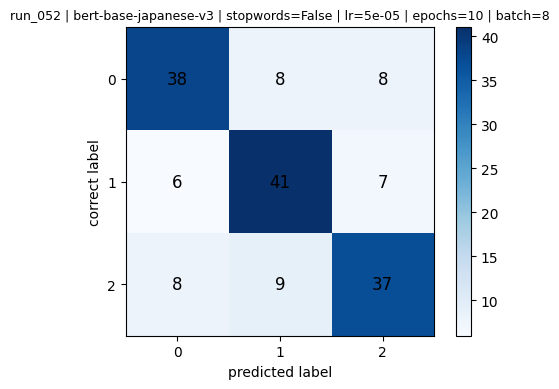

In [ ]:
# 実行例（コメントアウトを外して使用）
cm = plot_confusion_matrix_for_run("run_052")
